# Seminar 04: Matrix factorization and ALS

We derive **explicit-feedback ALS**, implement its alternating ridge-regression updates, and compare it with a popularity baseline, **SVD-style biased factorization** and **SVD++** on MovieLens 1M. The accompanying [PDF notes](https://drive.google.com/file/d/19V1fUJH7UDKdj_6F67eQIr-85oJgmdGV/view?usp=drivesdk) summarize the derivation and explain how implicit ALS differs.

**Learning goals:** distinguish missing ratings from zeros; understand ALS updates and regularization; keep validation separate from the final test; distinguish rating error from ranking quality; interpret the extra interaction-history term in SVD++.


In [57]:
from pathlib import Path
import os

SEED = 42
MAX_USERS = None  # None uses the complete MovieLens 1M dataset.
K = 10
POSITIVE_RATING = 4

# An override is useful for a local data mirror or an offline test.
if os.environ.get("RECSYS_ALS_DATA_DIR"):
    DATA_DIR = Path(os.environ["RECSYS_ALS_DATA_DIR"]).expanduser()
elif Path("/content").is_dir():
    DATA_DIR = Path("/content/recsys_als_data")
else:
    notebook_dir = Path.cwd()
    if not (notebook_dir / "seminar.ipynb").exists():
        notebook_dir = Path.cwd() / "seminars" / "04_als"
    DATA_DIR = notebook_dir / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory:", DATA_DIR.resolve())


Data directory: /content/recsys_als_data


## 1. Data and exploratory analysis

We use [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/) explicit ratings (1–5 stars). The first run downloads the archive from GroupLens; later runs reuse the cache. A missing rating is **unknown**, not a zero-star opinion. User and movie IDs are catalog identifiers, not matrix positions.


In [58]:
from urllib.request import urlretrieve
from zipfile import ZipFile

import numpy as np
import pandas as pd

ratings_path = DATA_DIR / "ml-1m" / "ratings.dat"
movies_path = DATA_DIR / "ml-1m" / "movies.dat"
if not (ratings_path.exists() and movies_path.exists()):
    archive_path = DATA_DIR / "ml-1m.zip"
    if not archive_path.exists():
        print("Downloading MovieLens 1M from GroupLens...", flush=True)
        urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", archive_path)
    with ZipFile(archive_path) as archive:
        for name in ("ml-1m/ratings.dat", "ml-1m/movies.dat"):
            archive.extract(name, DATA_DIR)

ratings_all = pd.read_csv(
    ratings_path, sep="::", engine="python",
    names=["user_id", "item_id", "rating", "timestamp"], encoding="latin-1"
)
movies = pd.read_csv(
    movies_path, sep="::", engine="python",
    names=["item_id", "title", "genres"], encoding="latin-1"
)
assert not ratings_all.duplicated(["user_id", "item_id"]).any()
if MAX_USERS is None:
    ratings = ratings_all.copy()
else:
    rng = np.random.default_rng(SEED)
    sampled_users = rng.choice(
        np.sort(ratings_all.user_id.unique()),
        size=min(MAX_USERS, ratings_all.user_id.nunique()), replace=False
    )
    ratings = ratings_all[ratings_all.user_id.isin(sampled_users)].copy()
print(f"{len(ratings):,} ratings; {ratings.user_id.nunique():,} users; "
      f"{ratings.item_id.nunique():,} rated movies")
ratings.head()


1,000,209 ratings; 6,040 users; 3,706 rated movies


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


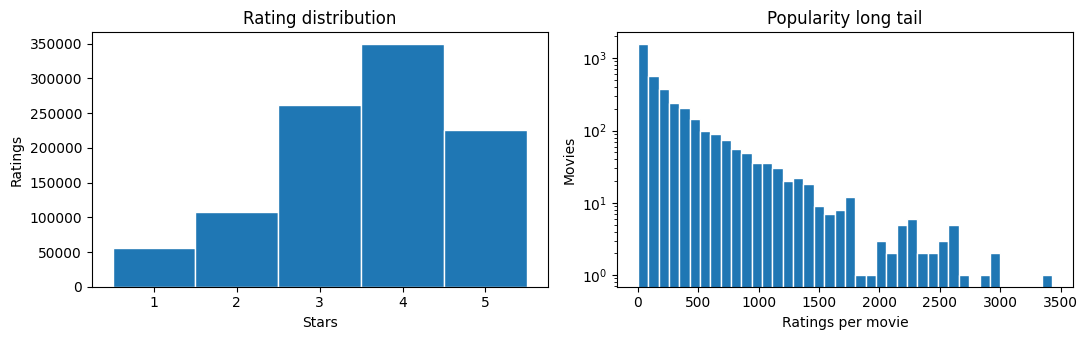

Observed density: 4.26%


In [59]:
import matplotlib.pyplot as plt

item_counts = ratings.groupby("item_id").size()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(ratings.rating, bins=np.arange(0.5, 6, 1), edgecolor="white")
axes[0].set(xlabel="Stars", ylabel="Ratings", title="Rating distribution")
axes[1].hist(item_counts, bins=40, edgecolor="white")
axes[1].set(xlabel="Ratings per movie", ylabel="Movies", title="Popularity long tail")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()
print(f"Observed density: {len(ratings) / (ratings.user_id.nunique() * movies.item_id.nunique()):.2%}")


## 2. Chronological train, validation and test

For each user, the last interaction is **test**, the preceding one is **validation**, and earlier interactions are **train**. Ties in timestamps are broken by item ID for a deterministic split. We select ALS settings on validation only; test is read once after model selection. Every model below sees the same training interactions at each stage.

Ranking metrics have a different target from rating error. A held-out rating counts as a relevant recommendation only when it is at least four stars. We also require the held-out movie to have appeared in training; this defines a warm-item ranking task. We report how many users remain eligible. RMSE/MAE use all warm-item held-out ratings, including low ratings.


In [60]:
from scipy import sparse

ratings = ratings.sort_values(["user_id", "timestamp", "item_id"], kind="stable").copy()
history_size = ratings.groupby("user_id").user_id.transform("size")
ratings = ratings[history_size >= 5].copy()
history_size = ratings.groupby("user_id").user_id.transform("size")
position = ratings.groupby("user_id").cumcount()
train_raw = ratings[position < history_size - 2].copy()
valid_raw = ratings[position == history_size - 2].copy()
test_raw = ratings[position == history_size - 1].copy()
assert len(valid_raw) == len(test_raw) == ratings.user_id.nunique()
assert set(train_raw.index).isdisjoint(valid_raw.index)
assert set(train_raw.index).isdisjoint(test_raw.index)
print(f"Train {len(train_raw):,} | validation {len(valid_raw):,} | test {len(test_raw):,}")

# Movie IDs are catalog metadata. Whether a movie is eligible for ranking is
# determined separately from training interactions at each stage.
user_ids = np.sort(ratings.user_id.unique())
item_ids = np.sort(movies.item_id.unique())
user_to_idx = {int(uid): i for i, uid in enumerate(user_ids)}
item_to_idx = {int(iid): i for i, iid in enumerate(item_ids)}
item_titles = dict(zip(movies.item_id, movies.title))
n_users, n_items = len(user_ids), len(item_ids)

def with_indices(frame):
    result = frame.copy()
    result["user_idx"] = result.user_id.map(user_to_idx).astype(int)
    result["item_idx"] = result.item_id.map(item_to_idx).astype(int)
    return result

train = with_indices(train_raw)
valid = with_indices(valid_raw)
test = with_indices(test_raw)

def rating_matrix(frame, binary=False):
    values = np.ones(len(frame), dtype=np.float64) if binary else frame.rating.to_numpy(dtype=np.float64)
    return sparse.csr_matrix(
        (values, (frame.user_idx.to_numpy(), frame.item_idx.to_numpy())),
        shape=(n_users, n_items), dtype=np.float64
    )

def known_items(frame):
    mask = np.zeros(n_items, dtype=bool)
    mask[frame.item_idx.to_numpy()] = True
    return mask

R_train = rating_matrix(train)
known_train = known_items(train)
print("Train matrix:", R_train.shape, "observed:", R_train.nnz)


Train 988,129 | validation 6,040 | test 6,040
Train matrix: (6040, 3883) observed: 988129


## 3. Explicit ALS: objective and update

Let $\Omega$ be the observed user–movie pairs. With user factors $U\in\mathbb{R}^{m\times d}$ and movie factors $V\in\mathbb{R}^{n\times d}$, predict $\hat r_{ui}=U_u^\top V_i$ and minimize

$$L(U,V)=\sum_{(u,i)\in\Omega}(r_{ui}-U_u^\top V_i)^2+\lambda\sum_u\|U_u\|_2^2+\lambda\sum_i\|V_i\|_2^2.$$

Holding $V$ fixed gives a ridge regression for user $u$. If $V_u$ contains factors for movies rated by that user, solve

$$(V_u^\top V_u+\lambda I)U_u=V_u^\top r_u.$$

The item update is symmetric. We call `np.linalg.solve` on these systems; explicitly inverting a matrix is unnecessary. This basic model has no global/user/movie bias, so its rating error should be interpreted alongside the mean baseline and the biased SVD models.


In [61]:
from contextlib import nullcontext

try:
    from threadpoolctl import threadpool_limits
except ImportError:
    def threadpool_limits(*args, **kwargs):
        return nullcontext()

def fit_with_one_blas_thread(model, matrix, validation=None):
    # Tiny normal-equation solves are much slower with many BLAS threads.
    with threadpool_limits(limits=1, user_api="blas"):
        if validation is None:
            return model.fit(matrix)
        return model.fit(matrix, validation=validation)

class ALSExplicit:
    def __init__(self, n_factors=32, n_iters=5, reg=10.0, random_state=42):
        if n_factors < 1 or n_iters < 1 or reg <= 0:
            raise ValueError("Require positive n_factors, n_iters and reg")
        self.n_factors, self.n_iters = n_factors, n_iters
        self.reg, self.random_state = reg, random_state

    def fit(self, matrix, validation=None):
        matrix = sparse.csr_matrix(matrix, dtype=np.float64)
        n_users_fit, n_items_fit = matrix.shape
        rng = np.random.default_rng(self.random_state)
        self.user_factors = 0.1 * rng.standard_normal((n_users_fit, self.n_factors))
        self.item_factors = 0.1 * rng.standard_normal((n_items_fit, self.n_factors))
        by_item = matrix.tocsc()
        active_users = np.flatnonzero(np.diff(matrix.indptr))
        active_items = np.flatnonzero(np.diff(by_item.indptr))
        self.user_factors[np.diff(matrix.indptr) == 0] = 0
        self.item_factors[np.diff(by_item.indptr) == 0] = 0
        eye = np.eye(self.n_factors)
        observed = matrix.tocoo()
        self.history_ = []

        for iteration in range(1, self.n_iters + 1):
            for u in active_users:
                start, end = matrix.indptr[u:u + 2]
                item_idx = matrix.indices[start:end]
                factors = self.item_factors[item_idx]
                self.user_factors[u] = np.linalg.solve(
                    factors.T @ factors + self.reg * eye,
                    factors.T @ matrix.data[start:end]
                )
            for i in active_items:
                start, end = by_item.indptr[i:i + 2]
                user_idx = by_item.indices[start:end]
                factors = self.user_factors[user_idx]
                self.item_factors[i] = np.linalg.solve(
                    factors.T @ factors + self.reg * eye,
                    factors.T @ by_item.data[start:end]
                )
            train_pred = self.predict_pairs(observed.row, observed.col)
            row = {"iteration": iteration,
                   "train_rmse": float(np.sqrt(np.mean((observed.data - train_pred) ** 2)))}
            if validation is not None:
                val_pred = self.predict_pairs(
                    validation.user_idx.to_numpy(), validation.item_idx.to_numpy()
                )
                row["valid_rmse"] = float(np.sqrt(np.mean(
                    (validation.rating.to_numpy() - val_pred) ** 2
                )))
            self.history_.append(row)
        return self

    def predict_pairs(self, user_idx, item_idx):
        return np.sum(self.user_factors[user_idx] * self.item_factors[item_idx], axis=1)

    def scores_for_user(self, user_idx):
        return self.item_factors @ self.user_factors[user_idx]

# A real low-rank matrix with masked entries: verify that fitting reduces error.
rng = np.random.default_rng(SEED)
true_u = rng.normal(1, 0.2, (24, 3))
true_v = rng.normal(1, 0.2, (32, 3))
complete = true_u @ true_v.T
row, col = np.where(rng.random(complete.shape) < 0.45)
toy = sparse.csr_matrix((complete[row, col], (row, col)), shape=complete.shape)
toy_model = fit_with_one_blas_thread(ALSExplicit(n_factors=3, n_iters=8, reg=0.1), toy)
assert toy_model.history_[-1]["train_rmse"] < toy_model.history_[0]["train_rmse"]
print("Toy RMSE:", round(toy_model.history_[0]["train_rmse"], 3), "→",
      round(toy_model.history_[-1]["train_rmse"], 3))


Toy RMSE: 2.546 → 0.027


## 4. A single evaluation protocol for every model

**RMSE/MAE** measure explicit rating prediction on warm movies. We clip every model's predicted ratings to the MovieLens 1–5 scale before computing them. **HitRate@10** and **NDCG@10** measure whether a single relevant held-out movie appears near the top of recommendations. Movies rated 1–3 are never counted as hits. Candidate movies must have appeared in training, and movies already seen by the user are removed. Catalog coverage is the share of warm candidate movies appearing in at least one user's top ten.

This is an offline leave-one-out evaluation: it cannot estimate online click lift, and its positive-only ranking subset should be reported with its user count.


In [62]:
def top_indices(scores, seen_indices, candidate_mask, k=10):
    masked = np.asarray(scores, dtype=float).copy()
    masked[~candidate_mask] = -np.inf
    masked[seen_indices] = -np.inf
    candidates = np.flatnonzero(np.isfinite(masked))
    if len(candidates) == 0:
        return np.array([], dtype=int)
    k = min(k, len(candidates))
    top = candidates[np.argpartition(-masked[candidates], k - 1)[:k]]
    return top[np.argsort(-masked[top], kind="stable")]

def rating_metrics(model, heldout, candidate_mask):
    eligible = heldout[heldout.item_idx.map(lambda idx: candidate_mask[idx])]
    if eligible.empty:
        return {"RMSE": np.nan, "MAE": np.nan, "rating_users": 0}
    user_idx = eligible.user_idx.to_numpy()
    item_idx = eligible.item_idx.to_numpy()
    predictions = np.clip(model.predict_pairs(user_idx, item_idx), 1, 5)
    errors = eligible.rating.to_numpy() - predictions
    return {"RMSE": float(np.sqrt(np.mean(errors ** 2))),
            "MAE": float(np.mean(np.abs(errors))),
            "rating_users": len(eligible)}

def ranking_metrics(model, history_matrix, heldout, candidate_mask, k=10):
    eligible = heldout[
        (heldout.rating >= POSITIVE_RATING)
        & heldout.item_idx.map(lambda idx: candidate_mask[idx])
    ]
    details = []
    recommended = set()
    for record in eligible.itertuples():
        seen = history_matrix.indices[
            history_matrix.indptr[record.user_idx]:history_matrix.indptr[record.user_idx + 1]
        ]
        top = top_indices(model.scores_for_user(record.user_idx), seen, candidate_mask, k)
        recommended.update(top.tolist())
        rank = np.flatnonzero(top == record.item_idx)
        rank = int(rank[0] + 1) if len(rank) else None
        details.append((record.user_idx, rank, len(seen)))
    ranks = [rank for _, rank, _ in details]
    summary = {
        f"HR@{k}": float(np.mean([rank is not None for rank in ranks])) if ranks else np.nan,
        f"NDCG@{k}": float(np.mean([
            1 / np.log2(rank + 1) if rank is not None else 0 for rank in ranks
        ])) if ranks else np.nan,
        "rank_users": len(details),
        "coverage": len(recommended) / candidate_mask.sum() if candidate_mask.sum() else np.nan,
    }
    return summary, pd.DataFrame(details, columns=["user_idx", "rank", "history_length"])

class Baseline:
    '''User mean for ratings; movie popularity for ranking.'''
    def __init__(self, matrix):
        counts = np.diff(matrix.indptr)
        self.global_mean = float(matrix.data.mean())
        self.user_mean = np.divide(
            np.asarray(matrix.sum(axis=1)).ravel(), counts,
            out=np.full(matrix.shape[0], self.global_mean), where=counts > 0
        )
        self.popularity = np.bincount(matrix.indices, minlength=matrix.shape[1]).astype(float)

    def predict_pairs(self, user_idx, item_idx):
        return self.user_mean[user_idx]

    def scores_for_user(self, user_idx):
        return self.popularity

baseline_valid = Baseline(R_train)
print("Validation eligible users:",
      ranking_metrics(baseline_valid, R_train, valid, known_train, K)[0]["rank_users"],
      "/", len(valid))


Validation eligible users: 3545 / 6040


## 5. Select ALS settings on validation

We compare a small, explicit grid so the runtime is predictable. `n_factors` controls capacity, `reg` controls shrinkage, and `n_iters` controls the number of alternating updates. Select by validation NDCG@10; test data play no role. For larger experiments, a separate tuning service or Optuna would be useful, but the same validation/test separation must remain.


In [69]:
# Keep model selection fast even when MAX_USERS=None; the final fit below still
# uses every selected user. This subsample is selected without test labels.
TUNE_MAX_USERS = 6040
if n_users > TUNE_MAX_USERS:
    rng = np.random.default_rng(SEED)
    tune_users = rng.choice(np.arange(n_users), size=TUNE_MAX_USERS, replace=False)
    tune_train = train[train.user_idx.isin(tune_users)]
    tune_valid = valid[valid.user_idx.isin(tune_users)]
else:
    tune_train, tune_valid = train, valid
R_tune = rating_matrix(tune_train)
known_tune = known_items(tune_train)
print(f"ALS tuning: {len(tune_valid)} users; final fit: {n_users} users")

ALS_CONFIGS = [
    {"n_factors": 16, "reg": 5.0, "n_iters": 4},
    {"n_factors": 16, "reg": 5.0, "n_iters": 10},
    {"n_factors": 32, "reg": 5.0, "n_iters": 4},
    {"n_factors": 32, "reg": 5.0, "n_iters": 10},
    {"n_factors": 32, "reg": 10.0, "n_iters": 4},
    {"n_factors": 32, "reg": 30.0, "n_iters": 10},
    {"n_factors": 32, "reg": 100.0, "n_iters": 10},
]
search_rows = []
validation_models = []
for config in ALS_CONFIGS:
    model = fit_with_one_blas_thread(
        ALSExplicit(**config, random_state=SEED), R_tune, validation=tune_valid
    )
    rank_summary, _ = ranking_metrics(model, R_tune, tune_valid, known_tune, K)
    error_summary = rating_metrics(model, tune_valid, known_tune)
    search_rows.append({**config, **rank_summary, **error_summary})
    validation_models.append(model)

search = pd.DataFrame(search_rows)
best_index = int(search[f"NDCG@{K}"].fillna(-1).idxmax())
best_config = ALS_CONFIGS[best_index]
best_validation_model = validation_models[best_index]
display(search.round(4))
print("Selected on validation:", best_config)


ALS tuning: 6040 users; final fit: 6040 users


,n_factors,reg,n_iters,HR@10,NDCG@10,rank_users,coverage,RMSE,MAE,rating_users
0,16,5.0,4,0.0615,0.0319,3545,0.2948,0.9284,0.7310,6040
1,16,5.0,10,0.0584,0.0291,3545,0.2910,0.9248,0.7274,6040
2,32,5.0,4,0.0578,0.0284,3545,0.3572,0.9684,0.7639,6040
3,32,5.0,10,0.0592,0.0289,3545,0.3275,0.9668,0.7590,6040
4,32,10.0,4,0.0629,0.0333,3545,0.2376,0.9564,0.7574,6040
5,32,30.0,10,0.0677,0.0340,3545,0.1220,1.0424,0.8361,6040
6,32,100.0,10,0.0542,0.0263,3545,0.0386,1.4301,1.1679,6040


Selected on validation: {'n_factors': 32, 'reg': 30.0, 'n_iters': 10}


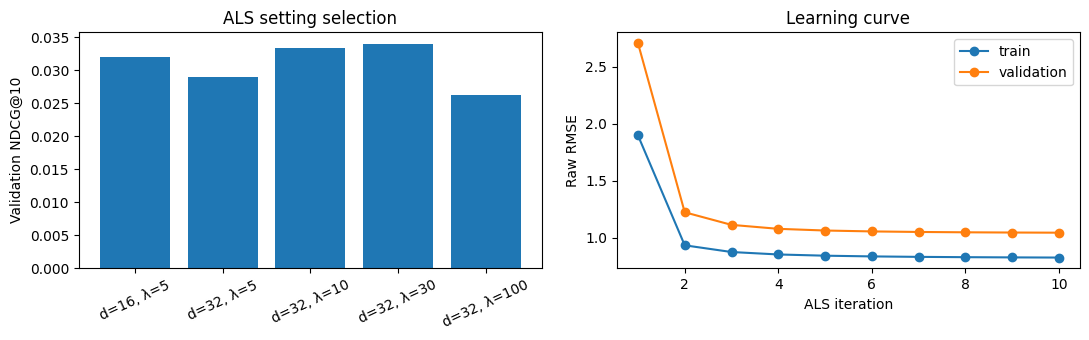

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
labels = [f"d={row.n_factors}, λ={row.reg:g}" for row in search.itertuples()]
axes[0].bar(labels, search[f"NDCG@{K}"])
axes[0].set(ylabel=f"Validation NDCG@{K}", title="ALS setting selection")
axes[0].tick_params(axis="x", rotation=25)
history = pd.DataFrame(best_validation_model.history_)
axes[1].plot(history.iteration, history.train_rmse, marker="o", label="train")
axes[1].plot(history.iteration, history.valid_rmse, marker="o", label="validation")
axes[1].set(xlabel="ALS iteration", ylabel="Raw RMSE", title="Learning curve")
axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Refit and compare factorization methods

After selection, refit on **train + validation** and evaluate the untouched test split. The baseline uses a user's mean for rating prediction and movie popularity for ranking. Our ALS minimizes observed squared error with no bias terms. The next model is a **biased matrix factorization trained by user-batch SGD**, often called SVD in recommender libraries; it is **not** a truncated singular-value decomposition of a zero-filled matrix. SVD++ adds a normalized sum of latent vectors for movies in the user's training history. These small NumPy implementations need no extra Colab installation. All methods receive the same interactions and warm-item candidate set.


### SVD-style and SVD++: objectives and updates

Here **SVD-style** means factorization fitted to observed ratings, not truncated matrix SVD. Let $\Omega$ be the set of observed user–movie pairs, $\mu$ the mean rating, $b_u,b_i$ the biases, and $p_u,q_i\in\mathbb R^d$ the latent factors. Then

$$\hat r_{ui}=\mu+b_u+b_i+p_u^\top q_i,$$

$$L_{\mathrm{SVD}}=\sum_{(u,i)\in\Omega}(r_{ui}-\hat r_{ui})^2+\lambda\!\left(\sum_u(b_u^2+\|p_u\|_2^2)+\sum_i(b_i^2+\|q_i\|_2^2)\right).$$

For one observed rating, let $e_{ui}=r_{ui}-\hat r_{ui}$. An SGD step for the factors is $p_u\leftarrow p_u+\eta(e_{ui}q_i-\lambda p_u)$, $q_i\leftarrow q_i+\eta(e_{ui}p_u-\lambda q_i)$. The implementation below averages each user's gradients across that user's ratings in one step; it updates movie factors for individual ratings.

In **SVD++**, $N(u)$ contains the movies in the user's training history. Their additional factors $y_j$ form

$$h_u=p_u+|N(u)|^{-1/2}\sum_{j\in N(u)}y_j,\qquad
\hat r_{ui}=\mu+b_u+b_i+q_i^\top h_u.$$

The objective sums squared errors over $\Omega$ and regularizes $b_u,b_i,p_u,q_i$ **and** $y_j$:

$$L_{\mathrm{SVD++}}=\sum_{(u,i)\in\Omega}(r_{ui}-\hat r_{ui})^2+
\lambda\!\left(\sum_u(b_u^2+\|p_u\|_2^2)+
\sum_i(b_i^2+\|q_i\|_2^2+\|y_i\|_2^2)\right).$$

Each error $e_{ui}$ contributes a term proportional to $e_{ui}q_i/\sqrt{|N(u)|}$ to the update of every $y_j$, $j\in N(u)$. The history term uses whether a movie was rated, not the rating value. These equations follow [Koren (2008)](https://www.cs.cornell.edu/courses/cs6241/2020sp/readings/Koren-2008-Factorization.pdf).


In [71]:
final_train = pd.concat([train, valid], ignore_index=True)
R_final = rating_matrix(final_train)
known_final = known_items(final_train)

als_final = fit_with_one_blas_thread(
    ALSExplicit(**best_config, random_state=SEED), R_final
)
baseline_final = Baseline(R_final)
print("Refitted ALS on", len(final_train), "ratings")


Refitted ALS on 994169 ratings


In [73]:
class BiasedFactorization:
    '''SVD-style factors; optionally add the SVD++ history term.'''
    def __init__(self, n_factors=32, n_epochs=15, use_history=False,
                 lr_user=0.08, lr_item=0.008, reg=0.02, random_state=42):
        self.n_factors, self.n_epochs = n_factors, n_epochs
        self.use_history = use_history
        self.lr_user, self.lr_item, self.reg = lr_user, lr_item, reg
        self.random_state = random_state

    def fit(self, matrix):
        matrix = sparse.csr_matrix(matrix, dtype=np.float64)
        n_users_fit, n_items_fit = matrix.shape
        rng = np.random.default_rng(self.random_state)
        self.global_mean = float(matrix.data.mean())
        self.user_factors = 0.05 * rng.standard_normal((n_users_fit, self.n_factors))
        self.item_factors = 0.05 * rng.standard_normal((n_items_fit, self.n_factors))
        self.history_factors = np.zeros((n_items_fit, self.n_factors))
        self.user_bias = np.zeros(n_users_fit)
        self.item_bias = np.zeros(n_items_fit)
        counts = np.diff(matrix.indptr)
        history = matrix.copy()
        history.data = np.repeat(
            np.divide(1, np.sqrt(counts), out=np.zeros_like(counts, dtype=float), where=counts > 0),
            counts
        )
        self.history_matrix = history
        self.history_ = []

        for epoch in range(1, self.n_epochs + 1):
            for u in rng.permutation(n_users_fit):
                start, end = matrix.indptr[u:u + 2]
                items = matrix.indices[start:end]
                if len(items) == 0:
                    continue
                ratings_u = matrix.data[start:end]
                old_q = self.item_factors[items].copy()
                history_term = (
                    self.history_factors[items].sum(axis=0) / np.sqrt(len(items))
                    if self.use_history else 0
                )
                effective_user = self.user_factors[u] + history_term
                prediction = (self.global_mean + self.user_bias[u]
                              + self.item_bias[items] + old_q @ effective_user)
                error = ratings_u - prediction
                mean_factor_gradient = error @ old_q / len(items)

                # Simultaneous gradients from the pre-update factors.
                self.user_bias[u] += self.lr_user * (error.mean() - self.reg * self.user_bias[u])
                self.user_factors[u] += self.lr_user * (
                    mean_factor_gradient - self.reg * self.user_factors[u]
                )
                self.item_bias[items] += self.lr_item * (
                    error - self.reg * self.item_bias[items]
                )
                self.item_factors[items] += self.lr_item * (
                    error[:, None] * effective_user - self.reg * old_q
                )
                if self.use_history:
                    self.history_factors[items] += self.lr_user * (
                        mean_factor_gradient / np.sqrt(len(items))
                        - self.reg * self.history_factors[items]
                    )
            observed = matrix.tocoo()
            effective_users = self.user_factors.copy()
            if self.use_history:
                effective_users += self.history_matrix @ self.history_factors
            fitted = (self.global_mean + self.user_bias[observed.row]
                      + self.item_bias[observed.col]
                      + np.sum(effective_users[observed.row]
                               * self.item_factors[observed.col], axis=1))
            rmse = float(np.sqrt(np.mean((observed.data - fitted) ** 2)))
            if not np.isfinite(rmse):
                raise FloatingPointError("Factorization diverged")
            self.history_.append({"epoch": epoch, "train_rmse": rmse})
        return self

    def scores_for_user(self, user_idx):
        effective_user = self.user_factors[user_idx].copy()
        if self.use_history:
            effective_user += (self.history_matrix[user_idx] @ self.history_factors).ravel()
        return (self.global_mean + self.user_bias[user_idx]
                + self.item_bias + self.item_factors @ effective_user)

    def predict_pairs(self, user_idx, item_idx):
        effective_users = self.user_factors.copy()
        if self.use_history:
            effective_users += self.history_matrix @ self.history_factors
        return (self.global_mean + self.user_bias[user_idx]
                + self.item_bias[item_idx]
                + np.sum(effective_users[user_idx] * self.item_factors[item_idx], axis=1))

MF_EPOCHS = 10 if n_users > 1000 else 15
svd = BiasedFactorization(n_epochs=MF_EPOCHS, random_state=SEED).fit(R_final)
svdpp = BiasedFactorization(
    n_epochs=MF_EPOCHS, use_history=True, random_state=SEED
).fit(R_final)
print(f"Factorization epochs: {MF_EPOCHS}")
assert svd.history_[-1]["train_rmse"] < svd.history_[0]["train_rmse"]
assert svdpp.history_[-1]["train_rmse"] < svdpp.history_[0]["train_rmse"]
print("Train RMSE, SVD-style:", round(svd.history_[-1]["train_rmse"], 4))
print("Train RMSE, SVD++:", round(svdpp.history_[-1]["train_rmse"], 4))


Factorization epochs: 10
Train RMSE, SVD-style: 0.9102
Train RMSE, SVD++: 0.8989


### Why popularity can outperform SVD on HitRate

SVD and SVD++ are trained to predict the **number of stars** for a rated movie. HitRate@10 asks a different question: can the model find one positive held-out movie among all unseen candidates? A predicted star rating alone does not estimate whether the user will encounter or watch a movie. In this evaluation, a movie's frequency in the training data is a strong signal. Low RMSE therefore need not imply high HitRate.

To make this distinction visible, the comparison retains the original SVD and SVD++ models and adds separate **popularity-adjusted hybrids**:

$$s_{ui}=\log(1+n_i)+\gamma(\hat r_{ui}-\mu),$$

Here $n_i$ is the movie's training rating count. At $\gamma=0$, candidates are ranked by popularity; for $\gamma>0$, the rating model can change their order. We select $\gamma$ using **validation NDCG@10 only**, then evaluate it once on the test set. The hybrids are not pure SVD/SVD++ results; their RMSE is identical to that of the corresponding rating model.


,model,gamma,HR@10,NDCG@10
0,SVD,0.00,0.0559,0.0271
1,SVD,0.25,0.0584,0.0286
2,SVD,0.50,0.0584,0.0285
3,SVD,1.00,0.0581,0.0288
4,SVD,2.00,0.0553,0.0255
5,SVD++,0.00,0.0559,0.0271
6,SVD++,0.25,0.0609,0.0295
7,SVD++,0.50,0.0609,0.0295
8,SVD++,1.00,0.0612,0.0296
9,SVD++,2.00,0.0578,0.0271


Selected on validation: {'SVD': 1.0, 'SVD++': 1.0}


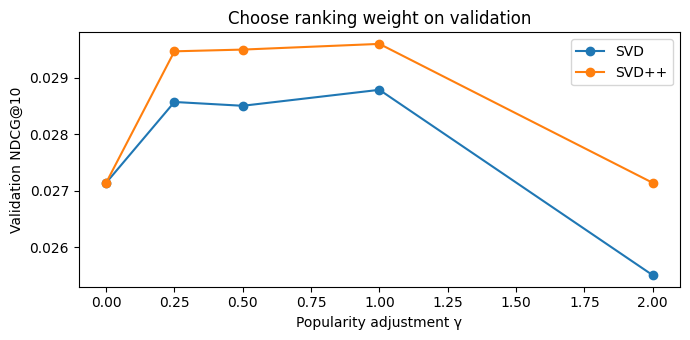

In [74]:
class PopularityAdjustedRanking:
    '''Keep the rating prediction; adjust only the recommendation score.'''
    def __init__(self, rating_model, training_matrix, gamma):
        self.rating_model = rating_model
        self.popularity_score = np.log1p(
            np.bincount(training_matrix.indices, minlength=training_matrix.shape[1])
        )
        self.gamma = gamma

    def predict_pairs(self, user_idx, item_idx):
        return self.rating_model.predict_pairs(user_idx, item_idx)

    def scores_for_user(self, user_idx):
        return (self.popularity_score + self.gamma *
                (self.rating_model.scores_for_user(user_idx)
                 - self.rating_model.global_mean))

GAMMA_GRID = [0.0, 0.25, 0.5, 1.0, 2.0]
hybrid_search_rows = []
selected_gamma = {}
for name, use_history in [("SVD", False), ("SVD++", True)]:
    tune_mf = BiasedFactorization(
        n_epochs=MF_EPOCHS, use_history=use_history, random_state=SEED
    ).fit(R_tune)
    for gamma in GAMMA_GRID:
        hybrid = PopularityAdjustedRanking(tune_mf, R_tune, gamma)
        metrics, _ = ranking_metrics(hybrid, R_tune, tune_valid, known_tune, K)
        hybrid_search_rows.append({"model": name, "gamma": gamma, **metrics})
    model_rows = [row for row in hybrid_search_rows if row["model"] == name]
    selected_gamma[name] = max(
        model_rows, key=lambda row: row[f"NDCG@{K}"]
    )["gamma"]

hybrid_search = pd.DataFrame(hybrid_search_rows)
display(hybrid_search[["model", "gamma", f"HR@{K}", f"NDCG@{K}"]].round(4))
print("Selected on validation:", selected_gamma)
svd_hybrid = PopularityAdjustedRanking(svd, R_final, selected_gamma["SVD"])
svdpp_hybrid = PopularityAdjustedRanking(svdpp, R_final, selected_gamma["SVD++"])

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, group in hybrid_search.groupby("model"):
    ax.plot(group.gamma, group[f"NDCG@{K}"], marker="o", label=name)
ax.set(xlabel="Popularity adjustment γ", ylabel=f"Validation NDCG@{K}",
       title="Choose ranking weight on validation")
ax.legend()
plt.tight_layout()
plt.show()


In [76]:
models = {
    "User mean / popularity": baseline_final,
    "Explicit ALS": als_final,
    "SVD-style (SGD)": svd,
    "SVD++ (SGD)": svdpp,
    "SVD + popularity": svd_hybrid,
    "SVD++ + popularity": svdpp_hybrid,
}
results = []
ranking_details = {}
for name, model in models.items():
    rating_result = rating_metrics(model, test, known_final)
    ranking_result, details = ranking_metrics(model, R_final, test, known_final, K)
    results.append({"model": name, **rating_result, **ranking_result})
    ranking_details[name] = details
comparison = pd.DataFrame(results).set_index("model")
print("Explicit rating prediction (lower error is better):")
display(comparison.iloc[:4][["RMSE", "MAE", "rating_users"]].round(4))
print(f"Positive-item recommendation (higher HR@{K} and NDCG@{K} are better):")
display(comparison[[f"HR@{K}", f"NDCG@{K}", "rank_users", "coverage"]].round(4))
print(f"Ranking eligibility: {comparison.rank_users.iloc[0]} / {len(test)} test users; "
      f"rating eligibility: {comparison.rating_users.iloc[0]} / {len(test)}")


Explicit rating prediction (lower error is better):


,RMSE,MAE,rating_users
model,,,
User mean / popularity,1.1081,0.8839,6038
Explicit ALS,1.0751,0.8596,6038
SVD-style (SGD),0.9711,0.7760,6038
SVD++ (SGD),0.9635,0.7698,6038


Positive-item recommendation (higher HR@10 and NDCG@10 are better):


,HR@10,NDCG@10,rank_users,coverage
model,,,,
User mean / popularity,0.0473,0.0226,3512,0.0408
Explicit ALS,0.0584,0.0284,3512,0.1210
SVD-style (SGD),0.0137,0.0060,3512,0.0154
SVD++ (SGD),0.0174,0.0078,3512,0.0254
SVD + popularity,0.0490,0.0230,3512,0.0364
SVD++ + popularity,0.0524,0.0249,3512,0.0381


Ranking eligibility: 3512 / 6040 test users; rating eligibility: 6038 / 6040


In [77]:
# Paired intervals show whether a small test difference is distinguishable
# from the variation between eligible users; the test is not used for tuning.
baseline_detail = ranking_details["User mean / popularity"]
uncertainty_rows = []
for name in ["Explicit ALS", "SVD-style (SGD)", "SVD++ (SGD)",
             "SVD + popularity", "SVD++ + popularity"]:
    detail = ranking_details[name]
    assert np.array_equal(detail.user_idx.to_numpy(), baseline_detail.user_idx.to_numpy())
    for metric, values in [
        (f"HR@{K}", detail["rank"].notna().to_numpy(dtype=float)
         - baseline_detail["rank"].notna().to_numpy(dtype=float)),
        (f"NDCG@{K}",
         np.where(detail["rank"].notna(), 1 / np.log2(detail["rank"].fillna(1) + 1), 0)
         - np.where(baseline_detail["rank"].notna(),
                    1 / np.log2(baseline_detail["rank"].fillna(1) + 1), 0)),
    ]:
        mean = float(values.mean())
        margin = float(1.96 * values.std(ddof=1) / np.sqrt(len(values)))
        uncertainty_rows.append({"model": name, "metric": metric,
                                 "delta vs baseline": mean,
                                 "95% lower": mean - margin,
                                 "95% upper": mean + margin})
display(pd.DataFrame(uncertainty_rows).round(4))


,model,metric,delta vs baseline,95% lower,95% upper
0,Explicit ALS,HR@10,0.0111,0.0025,0.0197
1,Explicit ALS,NDCG@10,0.0058,0.0011,0.0105
2,SVD-style (SGD),HR@10,-0.0336,-0.0415,-0.0257
3,SVD-style (SGD),NDCG@10,-0.0165,-0.0207,-0.0124
4,SVD++ (SGD),HR@10,-0.0299,-0.0376,-0.0222
5,SVD++ (SGD),NDCG@10,-0.0147,-0.0189,-0.0106
6,SVD + popularity,HR@10,0.0017,-0.0036,0.0070
7,SVD + popularity,NDCG@10,0.0005,-0.0018,0.0027
8,SVD++ + popularity,HR@10,0.0051,-0.0006,0.0108
9,SVD++ + popularity,NDCG@10,0.0023,-0.0003,0.0049


The intervals above use **paired differences for the same eligible users**. If an interval includes zero, a small gain over popularity is not established reliably. These intervals describe test uncertainty; they are not used to select model settings.


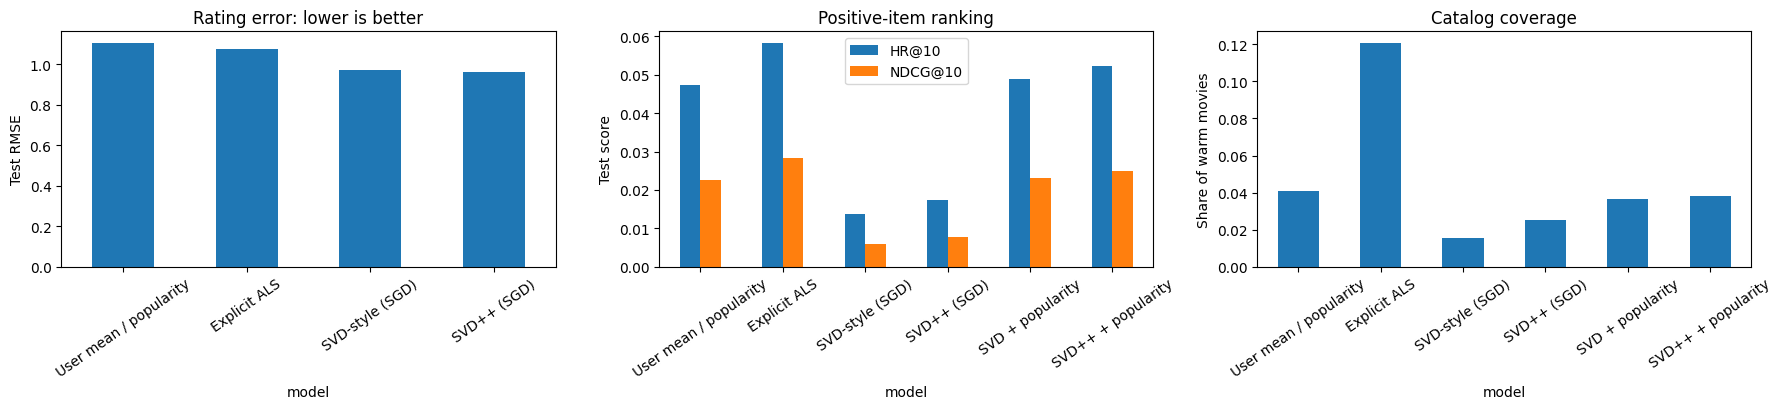

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
comparison.loc[comparison.index[:4], "RMSE"].plot.bar(
    ax=axes[0], title="Rating error: lower is better"
)
axes[0].set_ylabel("Test RMSE")
comparison[[f"HR@{K}", f"NDCG@{K}"]].plot.bar(ax=axes[1], title="Positive-item ranking")
axes[1].set_ylabel("Test score")
comparison["coverage"].plot.bar(ax=axes[2], title="Catalog coverage")
axes[2].set_ylabel("Share of warm movies")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


**How to read these results.** The rating table asks how accurately a model predicts the stars for an observed user–movie pair. The ranking table asks whether it retrieves one positive held-out movie from thousands of unseen candidates. The first baseline row uses a user mean for the former task and movie popularity for the latter. SVD and SVD++ optimize rating error, so their ranking scores are a transfer to a different task; lower HitRate does not mean they are worse at predicting ratings. Changing HitRate to another top-ten metric would not remove this mismatch. The implicit ALS experiment below instead trains on positive interactions and evaluates the same ranking target.


### Who benefits, and what is hidden by averages?

Group held-out positive interactions by the size of the user's training history. This plot is a **test diagnostic**, not a new tuning signal. A method can have good average ranking quality while underperforming on sparse histories. Coverage complements accuracy: a popularity model can repeatedly recommend a narrow set of blockbusters.


model,Explicit ALS,SVD + popularity,SVD++ (SGD),SVD++ + popularity,SVD-style (SGD),User mean / popularity
history_bin,,,,,,
31–100,0.057,0.043,0.014,0.049,0.011,0.043
>100,0.053,0.049,0.019,0.051,0.013,0.048
≤30,0.077,0.064,0.022,0.066,0.022,0.057


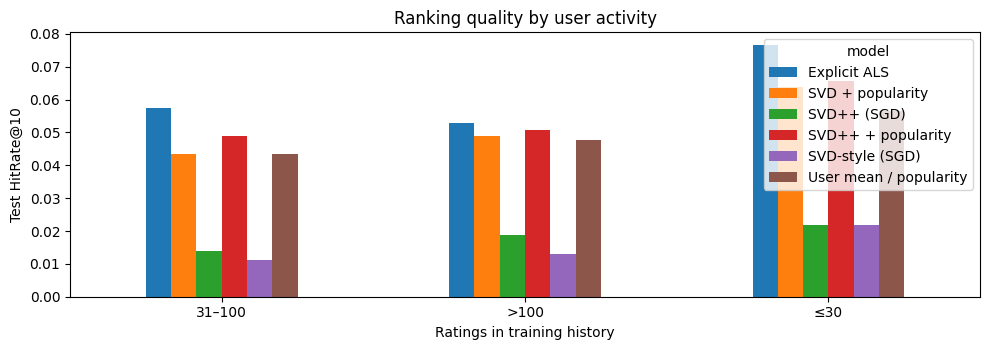

In [79]:
diagnostics = []
for name, details in ranking_details.items():
    grouped = details.copy()
    grouped["history_bin"] = pd.cut(
        grouped.history_length, bins=[0, 30, 100, np.inf],
        labels=["≤30", "31–100", ">100"]
    )
    for group_name, group in grouped.groupby("history_bin", observed=True):
        diagnostics.append({"model": name, "history_bin": group_name,
                            "HR": group["rank"].notna().mean(), "users": len(group)})
by_history = pd.DataFrame(diagnostics)
display(by_history.pivot(index="history_bin", columns="model", values="HR").round(3))
by_history.pivot(index="history_bin", columns="model", values="HR").plot.bar(figsize=(10, 3.6))
plt.ylabel(f"Test HitRate@{K}")
plt.xlabel("Ratings in training history")
plt.title("Ranking quality by user activity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Singular values: a useful diagnostic, not the same recommender

The classical singular-value decomposition $R=U\Sigma V^\top$ is defined for a **complete** matrix. Applying truncated SVD directly to the sparse rating matrix interprets missing entries as zeros. That solves a different objective from observed-only ALS and from our SVD-style factorization. The plot below shows the singular-value spectrum of that zero-filled matrix only as a structural diagnostic; it is **not** an unbiased rating-model comparison.


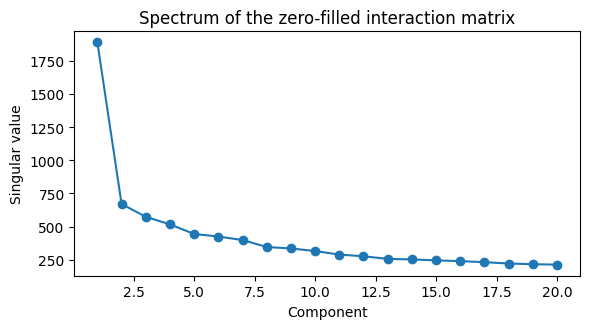

In [80]:
from scipy.sparse.linalg import svds

rank = min(20, min(R_final.shape) - 1)
singular_values = np.sort(svds(R_final.astype(float), k=rank, return_singular_vectors=False))[::-1]
plt.figure(figsize=(6, 3.4))
plt.plot(np.arange(1, rank + 1), singular_values, marker="o")
plt.xlabel("Component")
plt.ylabel("Singular value")
plt.title("Spectrum of the zero-filled interaction matrix")
plt.tight_layout()
plt.show()


## 8. Implicit ALS is a different task

For clicks, views or likes, define preference $p_{ui}\in\{0,1\}$ and confidence $c_{ui}=1+\alpha r_{ui}$ for observed interaction strength. Implicit ALS minimizes confidence-weighted error **over all user–item pairs**; unobserved pairs have low confidence rather than a known negative label. It is not the explicit-rating ALS above, and its scores should not be interpreted as stars.

As a small demonstration, treat ratings of at least four stars as positive interactions. We show recommendations but do not place this model in the explicit-rating RMSE table: its target and loss are different. A fair implicit comparison would define the positive-event protocol and candidate pool for all models separately.


### Implicit ALS: objective and update

Let $r_{ui}\geq0$ be the strength of a positive interaction, $p_{ui}=\mathbf 1[r_{ui}>0]$ the preference, and $c_{ui}=1+\alpha r_{ui}$ the confidence. For unobserved pairs, $p_{ui}=0$ and $c_{ui}=1$: this is a weak signal, not a confirmed negative response. The user factors $x_u$ and movie factors $y_i$ solve the objective of [Hu, Koren, and Volinsky (2008)](https://yifanhu.net/PUB/cf.pdf):

$$L_{\mathrm{implicit}}=\sum_{u,i}c_{ui}(p_{ui}-x_u^\top y_i)^2+
\lambda\!\left(\sum_u\|x_u\|_2^2+\sum_i\|y_i\|_2^2\right).$$

Fixing $Y$ and setting the derivative with respect to $x_u$ to zero gives the normal equation

$$(Y^\top C_uY+\lambda I)x_u=Y^\top C_up_u.$$

For the binary positive events used below, $r_{ui}=1$ on the set $I_u$. The system simplifies to

$$\left(Y^\top Y+\alpha\sum_{i\in I_u}y_iy_i^\top+\lambda I\right)x_u=
(1+\alpha)\sum_{i\in I_u}y_i.$$

After updating all $x_u$, we update $y_i$ symmetrically. Unlike explicit ALS, this objective also includes missing pairs.


In [81]:
class ALSImplicit:
    '''Confidence-weighted ALS for a binary positive-interaction matrix.'''
    def __init__(self, n_factors=16, n_iters=4, alpha=10.0,
                 reg=1.0, random_state=42):
        self.n_factors, self.n_iters = n_factors, n_iters
        self.alpha, self.reg, self.random_state = alpha, reg, random_state

    def fit(self, positive_matrix):
        positive_matrix = sparse.csr_matrix(positive_matrix, dtype=np.float64)
        by_item = positive_matrix.tocsc()
        n_users_fit, n_items_fit = positive_matrix.shape
        rng = np.random.default_rng(self.random_state)
        self.user_factors = np.zeros((n_users_fit, self.n_factors))
        self.item_factors = 0.05 * rng.standard_normal((n_items_fit, self.n_factors))
        eye = np.eye(self.n_factors)

        for _ in range(self.n_iters):
            item_gram = self.item_factors.T @ self.item_factors
            for u in range(n_users_fit):
                start, end = positive_matrix.indptr[u:u + 2]
                items = positive_matrix.indices[start:end]
                if len(items) == 0:
                    continue
                factors = self.item_factors[items]
                self.user_factors[u] = np.linalg.solve(
                    item_gram + self.alpha * (factors.T @ factors) + self.reg * eye,
                    (1 + self.alpha) * factors.sum(axis=0)
                )
            user_gram = self.user_factors.T @ self.user_factors
            for i in range(n_items_fit):
                start, end = by_item.indptr[i:i + 2]
                users = by_item.indices[start:end]
                if len(users) == 0:
                    self.item_factors[i] = 0
                    continue
                factors = self.user_factors[users]
                self.item_factors[i] = np.linalg.solve(
                    user_gram + self.alpha * (factors.T @ factors) + self.reg * eye,
                    (1 + self.alpha) * factors.sum(axis=0)
                )
        return self

    def scores_for_user(self, user_idx):
        return self.item_factors @ self.user_factors[user_idx]

positive_train = final_train[final_train.rating >= POSITIVE_RATING]
R_positive = rating_matrix(positive_train, binary=True)
implicit_model = fit_with_one_blas_thread(ALSImplicit(random_state=SEED), R_positive)
example_user_idx = int(final_train.user_idx.iloc[0])
seen_all = R_final.indices[
    R_final.indptr[example_user_idx]:R_final.indptr[example_user_idx + 1]
]
positive_ids = top_indices(
    implicit_model.scores_for_user(example_user_idx),
    seen_all, known_final, k=5
)
display(pd.DataFrame({
    "movie": [item_titles.get(int(item_ids[i]), "<unknown>") for i in positive_ids],
    "implicit_score": implicit_model.scores_for_user(example_user_idx)[positive_ids],
}))


,movie,implicit_score
0,"Lion King, The (1994)",0.955586
1,"Little Mermaid, The (1989)",0.852216
2,American Beauty (1999),0.832682
3,Ghostbusters (1984),0.816491
4,Raiders of the Lost Ark (1981),0.808179


### Ranking models trained on positive interactions

Here a rating of at least four stars is a positive event. Compare positive-event popularity with implicit ALS using the **same** test positives, warm-movie candidate set, and exclusion of every movie already rated in train + validation. Both methods are trained on positive interactions; neither score represents a predicted 1–5 star rating. The implicit ALS settings are fixed before looking at the test results.


In [82]:
positive_popularity = Baseline(R_positive)
positive_ranking_rows = []
positive_ranking_details = {}
for name, model in {
    "Positive-event popularity": positive_popularity,
    "Implicit ALS": implicit_model,
}.items():
    metrics, details = ranking_metrics(model, R_final, test, known_final, K)
    positive_ranking_rows.append({"model": name, **metrics})
    positive_ranking_details[name] = details
positive_ranking = pd.DataFrame(positive_ranking_rows).set_index("model")
display(positive_ranking[[f"HR@{K}", f"NDCG@{K}", "rank_users", "coverage"]].round(4))

base_hits = positive_ranking_details["Positive-event popularity"]["rank"].notna().to_numpy(dtype=float)
als_hits = positive_ranking_details["Implicit ALS"]["rank"].notna().to_numpy(dtype=float)
assert np.array_equal(
    positive_ranking_details["Positive-event popularity"].user_idx.to_numpy(),
    positive_ranking_details["Implicit ALS"].user_idx.to_numpy()
)
hit_difference = als_hits - base_hits
mean_difference = hit_difference.mean()
margin = 1.96 * hit_difference.std(ddof=1) / np.sqrt(len(hit_difference))
print(f"Implicit ALS minus positive popularity, paired HR@{K}: "
      f"{mean_difference:.4f} (approx. 95% CI "
      f"[{mean_difference - margin:.4f}, {mean_difference + margin:.4f}])")


,HR@10,NDCG@10,rank_users,coverage
model,,,,
Positive-event popularity,0.0493,0.0247,3512,0.0386
Implicit ALS,0.0999,0.0505,3512,0.2516


Implicit ALS minus positive popularity, paired HR@10: 0.0507 (approx. 95% CI [0.0402, 0.0612])


## 9. Inspect ALS recommendations

For one user, compare recent positive movies with top recommendations. The function below excludes every movie in the final training history and every movie without training interactions. Latent-factor scores are ranking scores; without bias terms and calibration, they are not necessarily valid 1–5 star estimates.


In [84]:
ials_final = fit_with_one_blas_thread(
    ALSImplicit(random_state=SEED), R_final
)

In [88]:
def recommend_als(raw_user_id, top_n=10):
    user_idx = user_to_idx[int(raw_user_id)]
    seen = R_final.indices[R_final.indptr[user_idx]:R_final.indptr[user_idx + 1]]
    top = top_indices(als_final.scores_for_user(user_idx), seen, known_final, top_n)
    return pd.DataFrame({
        "title": [item_titles.get(int(item_ids[i]), "<unknown>") for i in top],
        "score": als_final.scores_for_user(user_idx)[top]
    })

def recommend_ials(raw_user_id, top_n=10):
    user_idx = user_to_idx[int(raw_user_id)]
    seen = R_final.indices[R_final.indptr[user_idx]:R_final.indptr[user_idx + 1]]
    top = top_indices(ials_final.scores_for_user(user_idx), seen, known_final, top_n)
    return pd.DataFrame({
        "title": [item_titles.get(int(item_ids[i]), "<unknown>") for i in top],
        "score": als_final.scores_for_user(user_idx)[top]
    })

raw_user = int(test.user_id.iloc[0])
print("User:", raw_user)
recent = final_train[final_train.user_id == raw_user].sort_values("timestamp").tail(5)
display(recent[["item_id", "rating"]].assign(
    title=recent.item_id.map(item_titles)
)[["title", "rating"]])
display(recommend_als(raw_user))
display(recommend_ials(raw_user))

User: 1


,title,rating
47,"Hunchback of Notre Dame, The (1996)",4
48,Antz (1998),4
49,"Bug's Life, A (1998)",5
50,Hercules (1997),4
988129,Mulan (1998),4


,title,score
0,"Shawshank Redemption, The (1994)",4.603772
1,"Godfather, The (1972)",4.448550
2,"Silence of the Lambs, The (1991)",4.410717
3,Raiders of the Lost Ark (1981),4.387840
4,Forrest Gump (1994),4.365630
5,Life Is Beautiful (La Vita è bella) (1997),4.318885
6,Braveheart (1995),4.263886
7,Casablanca (1942),4.241971
8,Rear Window (1954),4.238174
9,"Bridge on the River Kwai, The (1957)",4.208304


,title,score
0,"Lion King, The (1994)",4.116756
1,Babe (1995),4.040531
2,American Beauty (1999),4.093222
3,"Shawshank Redemption, The (1994)",4.603772
4,"Silence of the Lambs, The (1991)",4.410717
5,Fantasia (1940),3.727301
6,Raiders of the Lost Ark (1981),4.387840
7,Star Wars: Episode VI - Return of the Jedi (1983),3.807766
8,Star Wars: Episode V - The Empire Strikes Back...,4.001970
9,Shakespeare in Love (1998),4.046758
